#Group5 Assignment: Implementation of Logistic Regression and LinearSVM


**Members:**
* Ablanque, Alex Jr.
* Bacuetes, Arcel Joy
* Bernados, Rey
* Carino, Brecht Algren
* Edio, Van Robert
* Galario, Aramina
* Torillo, Francis Rey


##I. Dataset

The fruit_data_with_colors.xlsx dataset contains **59 observations** with **7 variables**, including both numerical and categorical features. The target variable is fruit_name, which classifies fruits into apple, mandarin, orange, and lemon.

The dataset has no missing values and includes numerical features (mass, width, height, color_score) and categorical features (fruit_name, fruit_subtype). The fruit_label column is redundant and can be removed, while fruit_subtype may be optional depending on the level of detail needed. Feature scaling is important due to varying value ranges, and since the dataset is small, careful model evaluation is necessary to avoid overfitting.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report


In [ ]:
# load the dataset
df = pd.read_excel('/content/fruit_data_with_colors.xlsx')

# show info of the dataset
df.head()



,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [ ]:
# checking the columns
df.columns

Index(['fruit_label', 'fruit_name', 'fruit_subtype', 'mass', 'width', 'height',
       'color_score'],
      dtype='object')

In [ ]:
# showing the summary of the dataset
df. describe()

,fruit_label,mass,width,height,color_score
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.542373,163.118644,7.105085,7.693220,0.762881
std,1.208048,55.018832,0.816938,1.361017,0.076857
min,1.000000,76.000000,5.800000,4.000000,0.550000
25%,1.000000,140.000000,6.600000,7.200000,0.720000
50%,3.000000,158.000000,7.200000,7.600000,0.750000
75%,4.000000,177.000000,7.500000,8.200000,0.810000
max,4.000000,362.000000,9.600000,10.500000,0.930000


In [ ]:
# show the types of fruits in the dataset
df['fruit_name'].unique()

array(['apple', 'mandarin', 'orange', 'lemon'], dtype=object)

In [ ]:
# count each fruit in the dataset
df['fruit_name'].value_counts()


,count
fruit_name,
apple,19
orange,19
lemon,16
mandarin,5


# 1. HISTOGRAMS

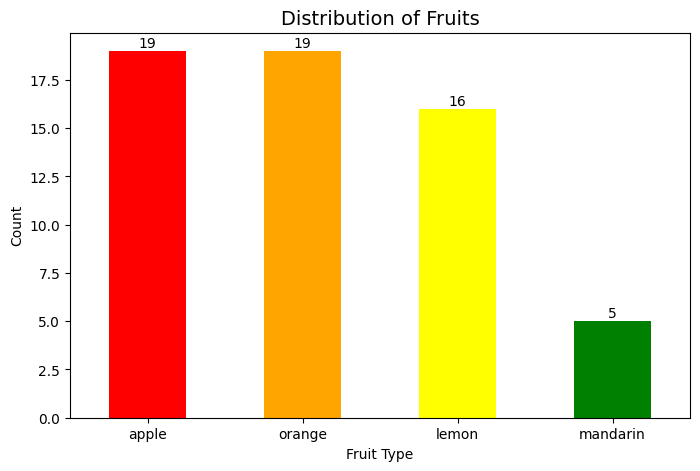

In [ ]:
import matplotlib.pyplot as plt

counts = df['fruit_name'].value_counts()
colors = ['red', 'orange', 'yellow', 'green']

plt.figure(figsize=(8,5))
counts.plot(kind='bar', color=colors)
plt.title("Distribution of Fruits", fontsize=14)
plt.xlabel("Fruit Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.show()

As you can see, the plot is not perfectly balance as some fruits appear more frequently than others. Such as, the apple and orange has the same higher counts while lemon has 16, and mandarin has 5 counts. Therefore,  the dataset is imbalance and can affect the performance of classification models, as models may become biased toward the more higher counts.

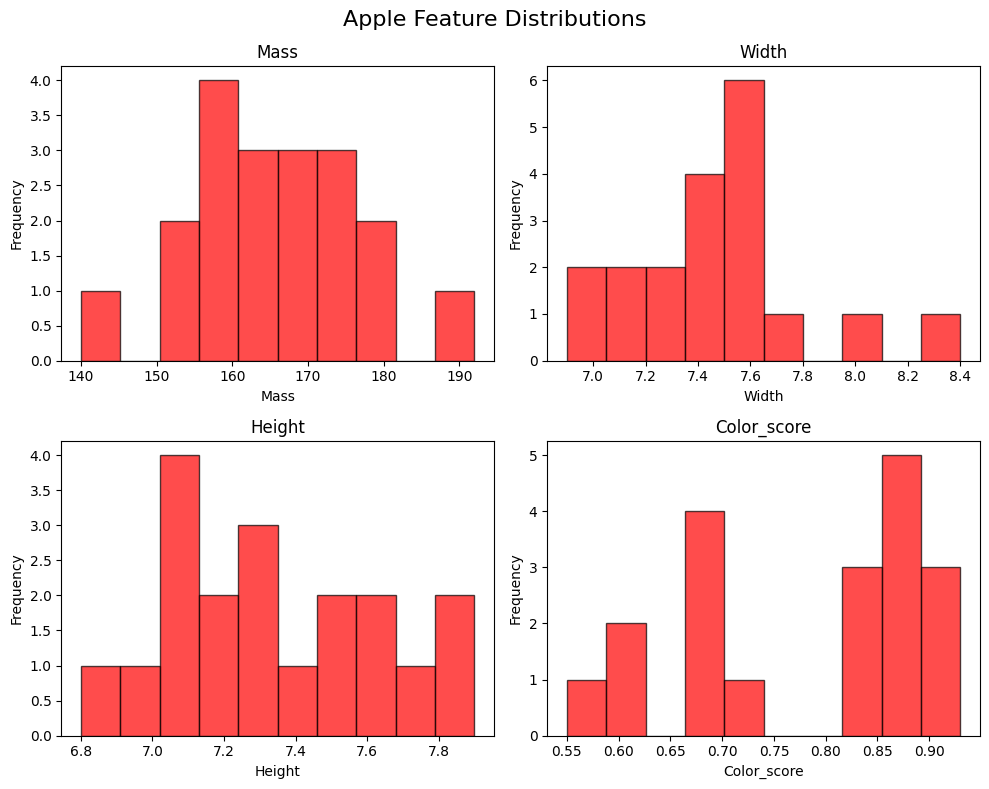

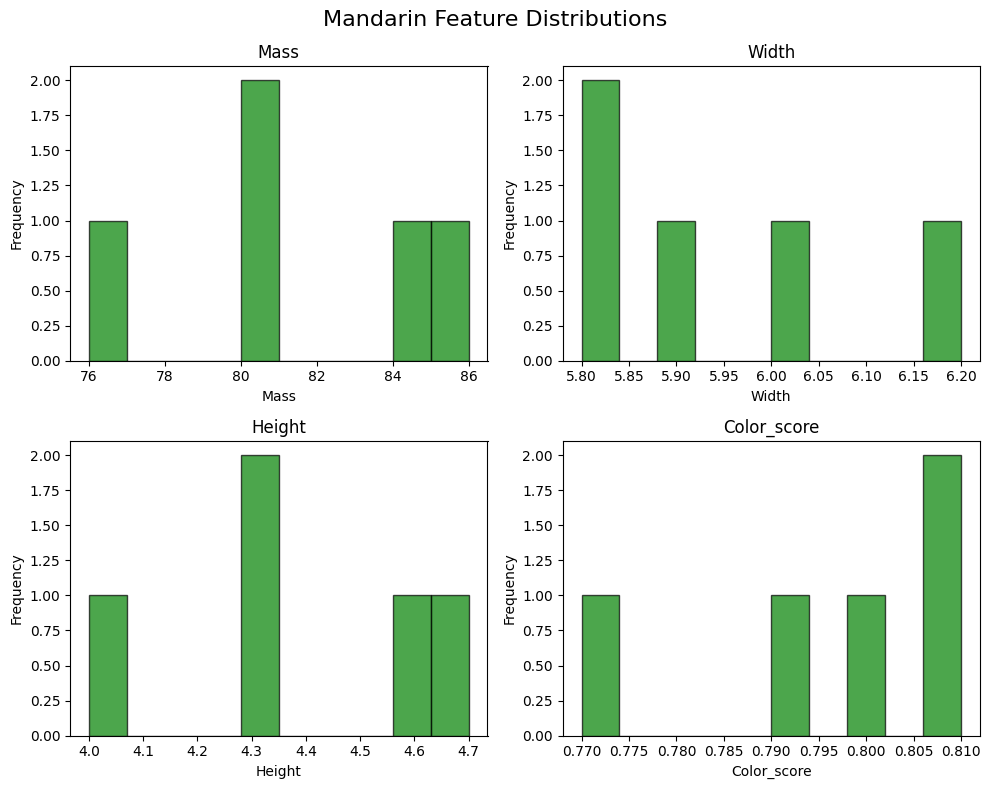

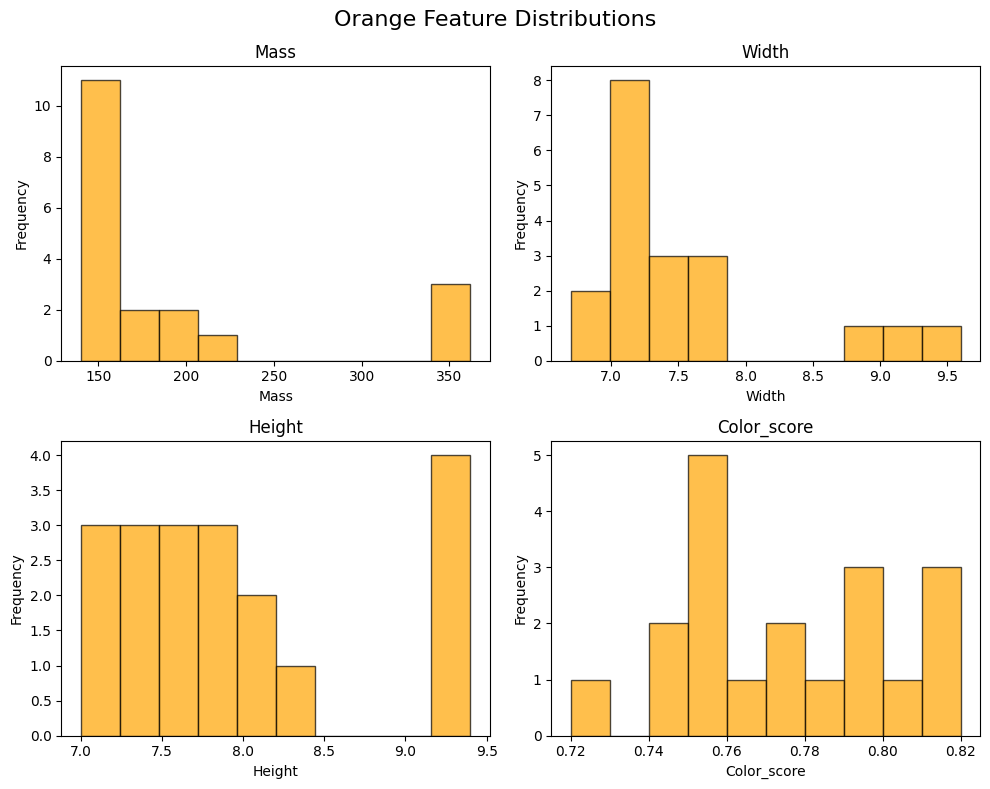

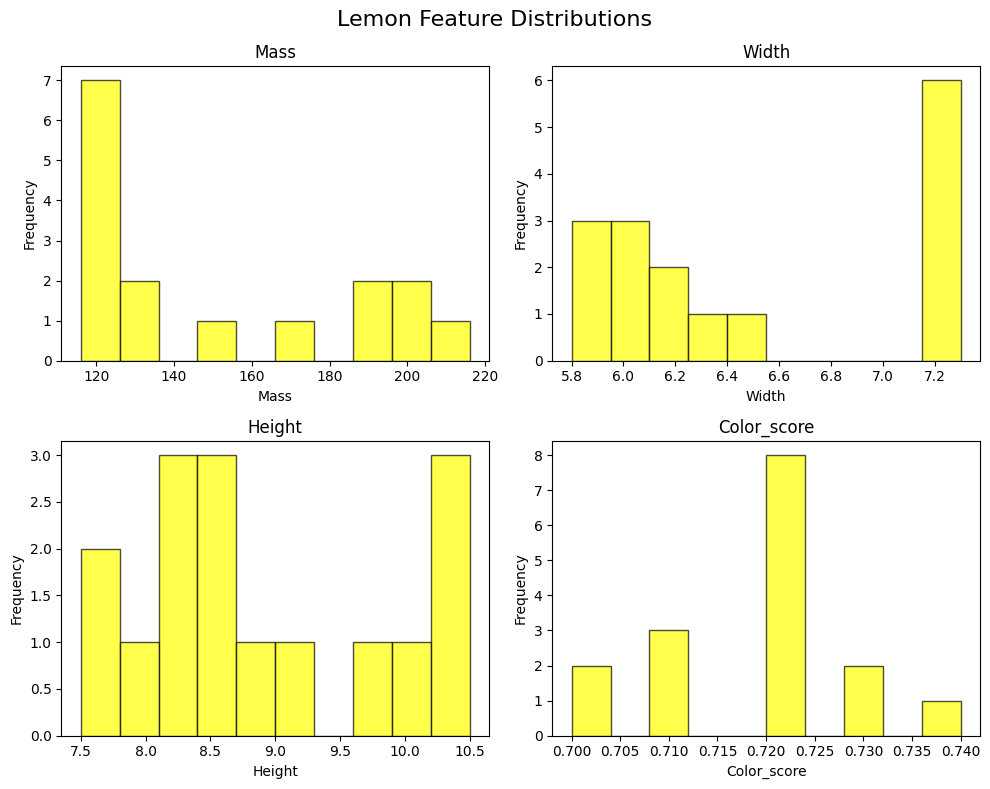

In [ ]:
import matplotlib.pyplot as plt

features = ['mass', 'width', 'height', 'color_score']
fruits = df['fruit_name'].unique()

fruit_colors = {
    'apple': 'red',
    'orange': 'orange',
    'lemon': 'yellow',
    'mandarin': 'green'
}

for fruit in fruits:
    subset = df[df['fruit_name'] == fruit]

    fig, axes = plt.subplots(2, 2, figsize=(10,8))
    fig.suptitle(f"{fruit.capitalize()} Feature Distributions", fontsize=16)

    axes = axes.flatten()

    for i, feature in enumerate(features):
        axes[i].hist(
            subset[feature],
            bins=10,
            color=fruit_colors.get(fruit, 'blue'),  # fallback color
            edgecolor='black',
            alpha=0.7
        )
        axes[i].set_title(feature.capitalize())
        axes[i].set_xlabel(feature.capitalize())
        axes[i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Interpretation of Per-Fruit Histograms

The per-fruit histograms provide a clearer view of how each feature behaves within a specific fruit type.

- Each fruit exhibits distinct ranges in features such as mass, width, and height.
- Some fruits show narrow distributions, indicating consistent physical characteristics.
- Other fruits display wider spreads, suggesting variability in size and shape.
- Color score tends to have overlapping ranges across fruits, making it a weaker distinguishing feature.

By isolating each fruit, it becomes easier to understand intra-class variation, which is important for model performance.

# 2. SCATTER PLOT AND PAITPLOT

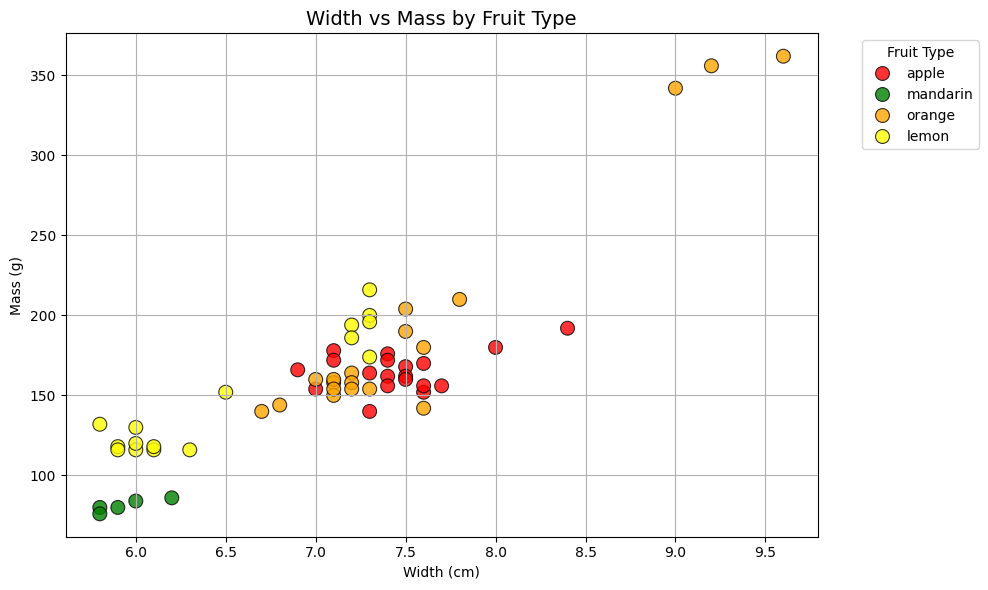

In [ ]:
fruit_colors = {
    'apple': 'red',
    'orange': 'orange',
    'lemon': 'yellow',
    'mandarin': 'green'
}

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='width',
    y='mass',
    hue='fruit_name',
    palette=fruit_colors,
    s=100,
    edgecolor='black',
    alpha=0.8
)

plt.title('Width vs Mass by Fruit Type', fontsize=14)
plt.xlabel('Width (cm)')
plt.ylabel('Mass (g)')
plt.legend(title='Fruit Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation of Scatterplot (Width vs Mass)

The scatterplot illustrates the relationship between fruit width and mass across different fruit types.

- A clear positive relationship is observed between width and mass, indicating that fruits with greater width tend to have higher mass.
- Distinct clustering is visible for each fruit type, suggesting that these two features are effective in differentiating between fruits.
- Apples and oranges form relatively separate clusters, showing minimal overlap, which makes them easier to classify.
- Some overlap may be observed between certain fruits (e.g., smaller oranges and larger mandarins), indicating potential areas where misclassification can occur.
- The consistency within clusters suggests that individual fruit types have similar physical characteristics.

Overall, the scatterplot demonstrates that width and mass are strong predictive features and contribute significantly to the effectiveness of classification models.

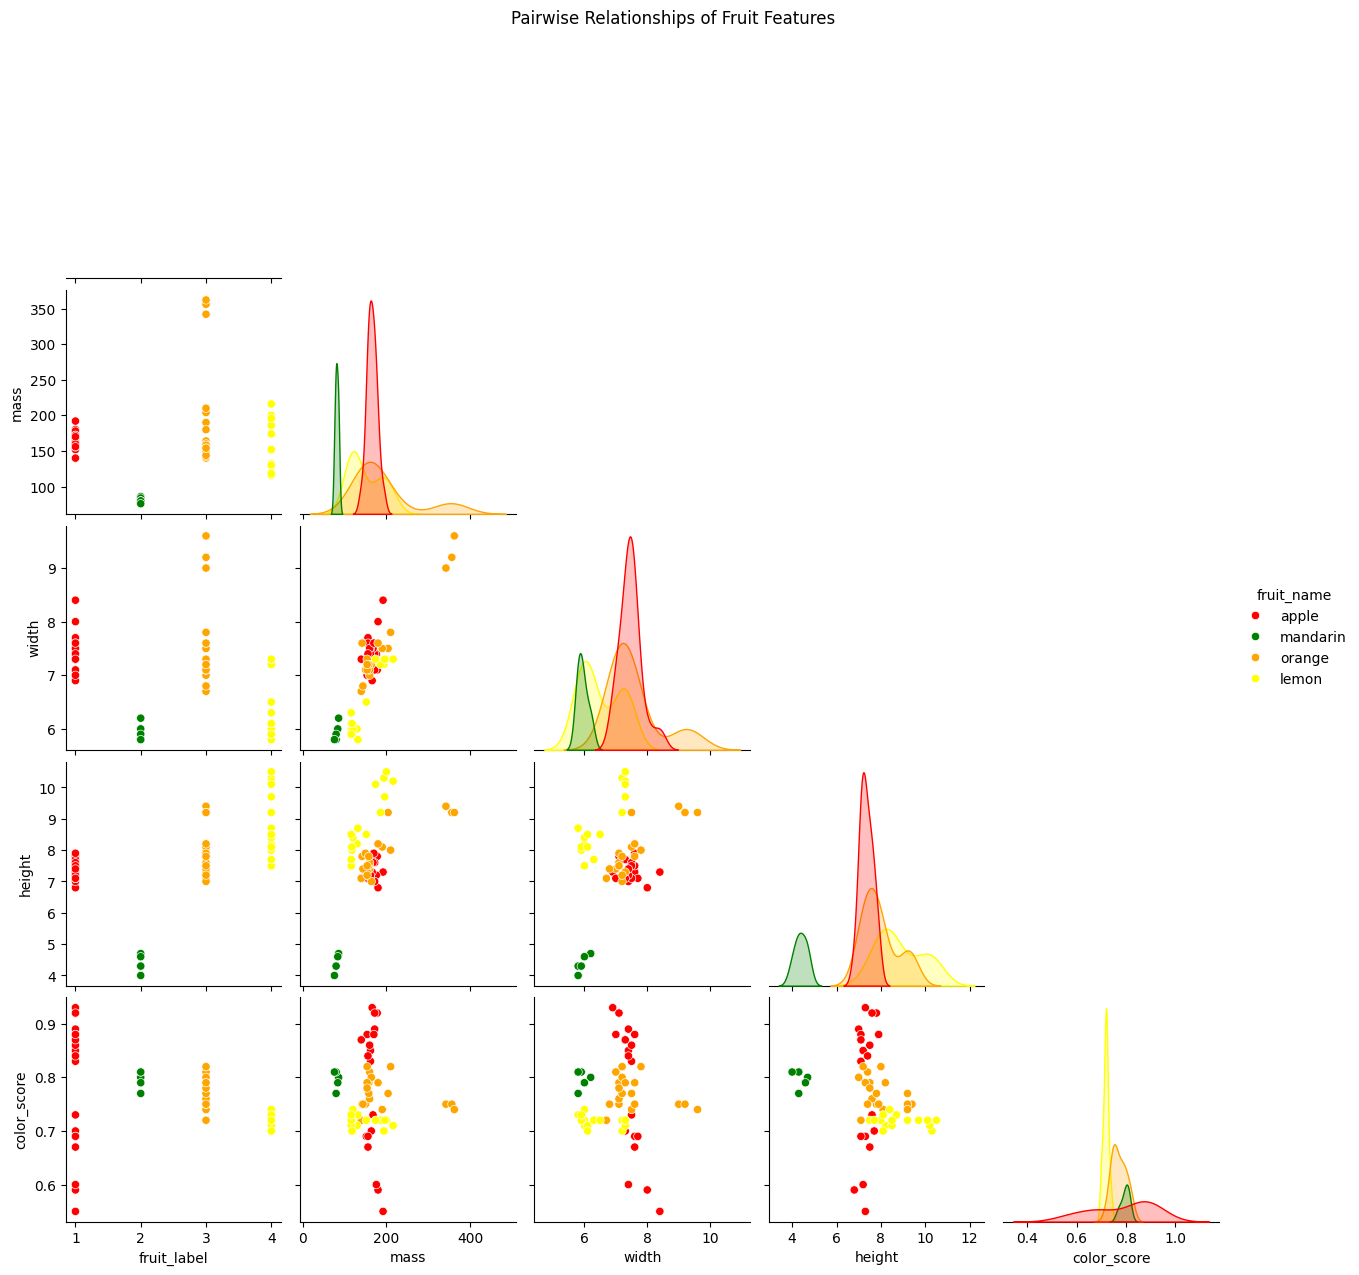

In [ ]:
sns.pairplot(
    df,
    hue='fruit_name',
    palette=fruit_colors,
    diag_kind='kde',
    corner=True
)

plt.suptitle("Pairwise Relationships of Fruit Features", y=1.02)
plt.show()

### Interpretation of Pairplot

The pairplot provides a comprehensive view of relationships between all numerical features.

- Distinct clusters can be observed for different fruit types, especially in combinations involving mass, width, and height.
- Some feature pairs show clear separation, indicating strong predictive power for classification.
- Overlapping regions are visible in certain areas, particularly involving color_score, suggesting potential classification challenges.
- The KDE reinforce earlier observations about feature distributions within each fruit.

Overall, the pairplot confirms that the dataset exhibits structured patterns that are suitable for machine learning models.

## **3. Machine Learning Models: kNN, Logistic Regression, and LinearSVM**

### Data Preparation

Before training the models, the dataset must be prepared properly.

- Selected numerical features: mass, width, height, and color_score
- Encoded the target variable (fruit_name) into numerical labels
- Split the dataset into training and testing sets using stratification
- Applied feature scaling to normalize values

Feature scaling is especially important for distance-based models such as kNN and SVM.

The LabelEncoder converts categorical fruit names into numerical labels so that machine learning models can process them.

In [ ]:
numeric_features = ["mass", "width", "height", "color_score"]

In [ ]:
X = df[numeric_features].values
y = df['fruit_name'].values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeatures used:", numeric_features)
print("\nTarget classes:", np.unique(y))

Feature matrix shape: (59, 4)
Target vector shape: (59,)

Features used: ['mass', 'width', 'height', 'color_score']

Target classes: ['apple' 'lemon' 'mandarin' 'orange']


In [ ]:
#(75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting set distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 44
Testing set size: 15

Training set distribution:
orange      14
apple       14
lemon       12
mandarin     4
Name: count, dtype: int64

Testing set distribution:
orange      5
apple       5
lemon       4
mandarin    1
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMean of scaled training features (should be close to 0):")
print(np.mean(X_train_scaled, axis=0))
print("\nStd of scaled training features (should be close to 1):")
print(np.std(X_train_scaled, axis=0))


Mean of scaled training features (should be close to 0):
[-5.04646829e-17 -6.10149557e-16  8.41498588e-16 -9.08364293e-16]

Std of scaled training features (should be close to 1):
[1. 1. 1. 1.]


### k-Nearest Neighbors (kNN)

kNN is a distance-based algorithm that classifies a data point based on the majority class of its nearest neighbors.

Key characteristics:
- Sensitive to feature scaling
- Performance depends on the choice of k
- Works well when data has clear clusters

In [ ]:
# 3.2 K-Nearest Neighbors (kNN)
knn = KNeighborsClassifier(n_neighbors=5) # You can adjust n_neighbors
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"kNN Accuracy (n_neighbors=5): {accuracy_knn:.4f}")

#KNearest Neighbors (kNN) Cross-Validation ---")
# Define the parameter grid for n_neighbors
param_grid_knn = {'n_neighbors': range(1, 20)}

# Perform GridSearchCV for kNN
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train)

print(f"Best kNN n_neighbors: {grid_search_knn.best_params_['n_neighbors']}")
print(f"Best kNN Cross-Validation Accuracy: {grid_search_knn.best_score_:.4f}")

# Re-train kNN with best n_neighbors and get predictions for classification report
best_knn = KNeighborsClassifier(n_neighbors=grid_search_knn.best_params_['n_neighbors'])
best_knn.fit(X_train_scaled, y_train)
y_pred_knn_best = best_knn.predict(X_test_scaled)

print("\n--- Classification Report for kNN (with best n_neighbors) ---")
print(classification_report(y_test, y_pred_knn_best, target_names=le.classes_))

kNN Accuracy (n_neighbors=5): 0.9333


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best kNN n_neighbors: 4
Best kNN Cross-Validation Accuracy: 0.9306

--- Classification Report for kNN (with best n_neighbors) ---
              precision    recall  f1-score   support

       apple       1.00      0.80      0.89         5
       lemon       1.00      1.00      1.00         4
    mandarin       1.00      1.00      1.00         1
      orange       0.83      1.00      0.91         5

    accuracy                           0.93        15
   macro avg       0.96      0.95      0.95        15
weighted avg       0.94      0.93      0.93        15



The k-Nearest Neighbors (kNN) model achieved a strong overall performance in classifying fruit types using the selected features, with an initial accuracy of 93.33% (k=5) and a slightly optimized cross-validation accuracy of 93.06% (k=4). This consistency between test and cross-validation results suggests that the model is stable and generalizes well to unseen data. However, a warning indicates that one class is underrepresented, which may slightly affect the reliability of cross-validation due to uneven class distribution across folds.
From the classification report, the model shows excellent performance for most classes, particularly lemon and mandarin, both achieving perfect precision and recall. Orange is also well-classified in terms of recall (1.00), though with lower precision (0.83), meaning some non-orange samples are occasionally misclassified as orange. Apple shows slightly weaker performance, with a recall of 0.80, indicating some apples are being misclassified into other categories. Overall, the model demonstrates strong predictive ability (F1-scores around 0.93–0.95), though minor class imbalance and overlap between similar fruit features likely contribute to the observed misclassifications.


--- Confusion Matrix for kNN (with best n_neighbors) ---


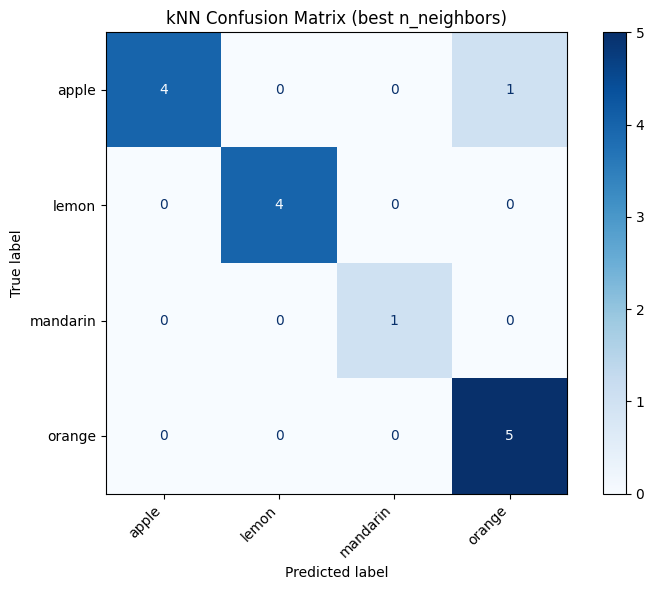

In [ ]:
# Confusion Matrix for kNN
print("\n--- Confusion Matrix for kNN (with best n_neighbors) ---")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_best, display_labels=le.classes_, cmap=plt.cm.Blues, ax=ax)
ax.set_title("kNN Confusion Matrix (best n_neighbors)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Logistic Regression

Logistic Regression is a linear model used for classification.

Key characteristics:
- Assumes linear decision boundaries
- Less sensitive to noise
- Works well when classes are linearly separable

In [ ]:
param_grid_log = {'C': [0.01, 0.1, 1, 10]}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=200),
    param_grid_log,
    cv=5,
    scoring='accuracy'
)

grid_log.fit(X_train_scaled, y_train)

best_log = grid_log.best_estimator_
y_pred_log = best_log.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Best C: {grid_log.best_params_['C']}")
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best C: 10
Logistic Regression Accuracy: 0.8667


The Logistic Regression model was optimized using GridSearchCV over different values of the regularization parameter C, and the best-performing value was C = 10. This indicates that a weaker regularization strength yielded better performance, allowing the model to fit the training data more flexibly. The final test accuracy achieved was 86.67%, which is lower compared to the kNN model, suggesting that Logistic Regression is slightly less effective for this dataset’s structure and feature relationships.

However, the cross-validation process also triggered a warning about class imbalance, where one class has only 4 samples, making the 5-fold split less reliable for that minority class. This imbalance may have affected model training stability and contributed to reduced performance. Overall, while Logistic Regression still performs reasonably well, it appears less capable than kNN in capturing the non-linear separations between fruit classes in this dataset.


--- Confusion Matrix for Logistic Regression (best C) ---


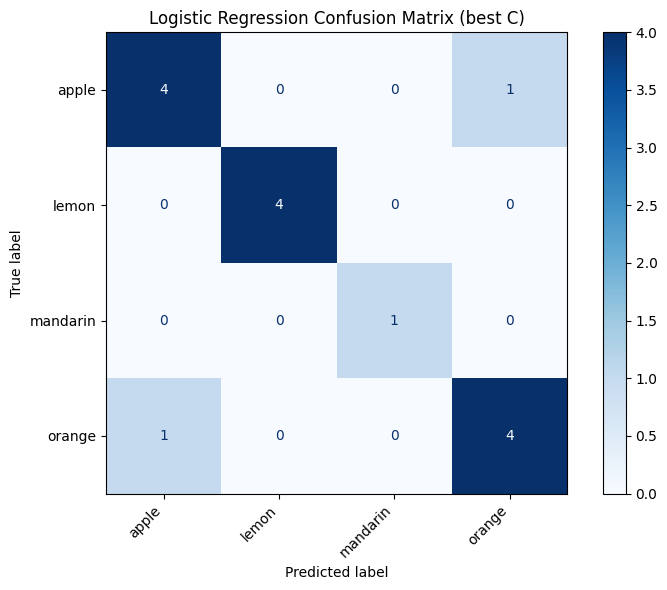

In [ ]:
# Confusion Matrix for Logistic Regression
print("\n--- Confusion Matrix for Logistic Regression (best C) ---")
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=le.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix (best C)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Linear Support Vector Machine (SVM)

Linear SVM finds the optimal hyperplane that maximizes the margin between classes.

Key characteristics:
- Effective in high-dimensional spaces
- Robust to overfitting
- Sensitive to feature scaling

In [ ]:
param_grid_svm = {'C': [0.01, 0.1, 1, 10]}

grid_svm = GridSearchCV(
    LinearSVC(max_iter=2000),
    param_grid_svm,
    cv=5,
    scoring='accuracy'
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Best C: {grid_svm.best_params_['C']}")
print(f"Linear SVM Accuracy: {accuracy_svm:.4f}")

Best C: 10
Linear SVM Accuracy: 0.8000


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


The Linear Support Vector Machine (SVM) model achieved a best performance at C = 10, indicating that a lower regularization penalty improved its ability to fit the training data more closely. However, despite tuning, the model obtained a test accuracy of only 80.00%, which is lower than both kNN and Logistic Regression. This suggests that a linear decision boundary is not sufficiently flexible to capture the underlying relationships between the fruit classes using the given features.

Overall, the results indicate that Linear SVM is less suitable for this dataset compared to the other models tested. The lower accuracy implies that the classes are not perfectly linearly separable, which limits the effectiveness of a linear kernel. This further supports the idea that models like kNN, which can capture more complex and non-linear patterns in the data, are better suited for this classification task.


--- Confusion Matrix for Linear SVM ---


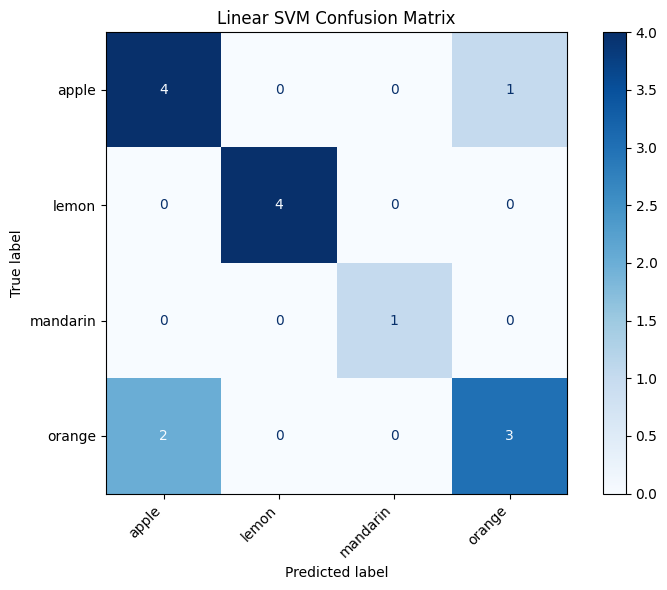

In [ ]:
print("\n--- Confusion Matrix for Linear SVM ---")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=le.classes_, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Linear SVM Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Model Comparison**

In [ ]:
results = pd.DataFrame({
    'Model': ['kNN', 'Logistic Regression', 'Linear SVM'],
    'Accuracy': [accuracy_knn, accuracy_log, accuracy_svm]
})

results

,Model,Accuracy
0,kNN,0.933333
1,Logistic Regression,0.866667
2,Linear SVM,0.800000


The results show that k-Nearest Neighbors (kNN) performed the best among the three models, achieving the highest accuracy of 93.33%, indicating that it was most effective in capturing the patterns and similarities among the fruit features. This suggests that the dataset likely contains non-linear relationships that kNN can better model compared to linear methods.

In comparison, Logistic Regression achieved a moderate accuracy of 86.67%, while Linear SVM performed the lowest at 80.00%. The decreasing performance from kNN to linear models suggests that the data is not strictly linearly separable, making distance-based learning (kNN) more suitable for this classification task than linear decision boundary methods.

## **Key Learning Points**

### **1. Importance of Feature Scaling in Distance-Based Models**

Feature scaling played a critical role in ensuring fair performance across all models, especially kNN and Linear SVM. Since these models rely on distance calculations, unscaled features would have caused features with larger numeric ranges (like mass) to dominate the results. Standardization allowed all features to contribute equally to model decisions. This directly improved classification reliability and stability.

### **2. kNN Performed Best Due to Clear Data Clustering**

The k-Nearest Neighbors model achieved the highest accuracy at 93.33%, with an optimal value of k = 5. This suggests that the dataset has well-formed clusters where nearby data points share similar labels. The strong performance indicates that local similarity is a powerful assumption for this dataset. However, kNN may still be sensitive to noisy or overlapping data regions.

### **3. Linear Models Show Moderate but Stable Performance**

Logistic Regression and Linear SVM achieved accuracies of 86.67% and 80.00%, respectively, with both using C = 10 as the best parameter. These results indicate that the dataset has partially linear decision boundaries but is not fully linearly separable. Logistic Regression performed better than Linear SVM in this case, suggesting it handled class overlap more effectively. However, both models are still limited compared to kNN due to their linear assumptions.

### **4. Model Performance Reflects Data Structure and Separability**

The differences in model performance highlight the underlying structure of the dataset. The strong kNN performance suggests clear local groupings among fruit classes, while the weaker linear model performance indicates overlapping class boundaries. This comparison demonstrates how different algorithms capture different types of patterns in data. It also reinforces the importance of selecting models based on dataset characteristics rather than relying on a single approach.

### **Final Conclusion**

This study successfully applied three machine learning algorithms—k-Nearest Neighbors (kNN), Logistic Regression, and Linear Support Vector Machine (SVM)—to classify fruit types based on physical attributes such as mass, width, height, and color score. The results showed that kNN achieved the highest accuracy at 93.33%, followed by Logistic Regression at 86.67%, and Linear SVM at 80.00%, with optimal parameters of k = 5 for kNN and C = 10 for both Logistic Regression and Linear SVM. These results indicate that the dataset exhibits strong local clustering patterns, which favor distance-based approaches like kNN. While linear models performed reasonably well, their lower accuracy suggests that the data is only partially linearly separable and contains overlapping class boundaries. Overall, this experiment demonstrates how different machine learning algorithms respond differently to the same dataset, emphasizing the importance of understanding data structure when selecting models for classification tasks.